# 04 - Modeling

## Goal
In this notebook, we build and evaluate machine learning models to predict medical appointment no-shows.

Because the target variable is highly imbalanced, we will focus on metrics such as:
- Recall
- Precision
- F1-score
- ROC-AUC
- PR-AUC

We will begin with a Logistic Regression baseline using class balancing, then compare it with stronger tree-based models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/medical_no_show_preprocessed.csv")
df.head()

,specialty,gender,no_show,disability,city,appointment_month,appointment_year,appointment_shift,age,under_12_years_old,...,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_day_of_week,appointment_hour,age_missing,weather_missing
0,physiotherapy,M,1,Missing,Missing,sept,2021,afternoon,NaN,0,...,23.7,0.2,1,1,no_rain,mild,Thursday,13,True,False
1,psychotherapy,M,0,Missing,Missing,sept,2021,afternoon,NaN,0,...,23.7,0.2,1,1,no_rain,mild,Thursday,13,True,False
2,speech therapy,F,0,Missing,Missing,sept,2021,afternoon,NaN,0,...,23.7,0.2,1,1,no_rain,mild,Thursday,13,True,False
3,physiotherapy,F,0,Missing,Missing,sept,2021,afternoon,NaN,0,...,23.7,0.2,1,1,no_rain,mild,Thursday,13,True,False
4,physiotherapy,M,0,motor,B. CAMBORIU,sept,2021,afternoon,68.0,0,...,23.7,0.2,1,1,no_rain,mild,Thursday,14,False,False


In [3]:
X = df.drop(columns=["no_show"])
y = df["no_show"]

In [4]:
X.shape, y.shape

((49593, 23), (49593,))

In [5]:
y.value_counts(normalize=True).round(4) * 100

no_show
0    90.26
1     9.74
Name: proportion, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(4) * 100)
print(y_test.value_counts(normalize=True).round(4) * 100)

(39674, 23) (9919, 23)
no_show
0    90.26
1     9.74
Name: proportion, dtype: float64
no_show
0    90.26
1     9.74
Name: proportion, dtype: float64


In [8]:
categorical_features = [
    "specialty",
    "gender",
    "disability",
    "city",
    "appointment_month",
    "appointment_shift",
    "rain_intensity",
    "heat_intensity",
    "appointment_day_of_week"
]

numeric_features = [
    "appointment_year",
    "age",
    "average_temp_day",
    "average_rain_day",
    "max_temp_day",
    "max_rain_day",
    "appointment_hour"
]

binary_features = [
    "under_12_years_old",
    "over_60_years_old",
    "patient_needs_companion",
    "rainy_day_before",
    "storm_day_before",
    "age_missing",
    "weather_missing"
]

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [10]:
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)



In [13]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [15]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

In [16]:
y_pred[:10]

array([1, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [17]:
y_proba[:10]

array([0.58259682, 0.44249792, 0.52642595, 0.32726809, 0.24385114,
       0.3350609 , 0.50653665, 0.39789045, 0.409257  , 0.58196467])

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72      8953
           1       0.14      0.62      0.23       966

    accuracy                           0.59      9919
   macro avg       0.54      0.60      0.48      9919
weighted avg       0.86      0.59      0.68      9919



In [19]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.638
PR-AUC: 0.152


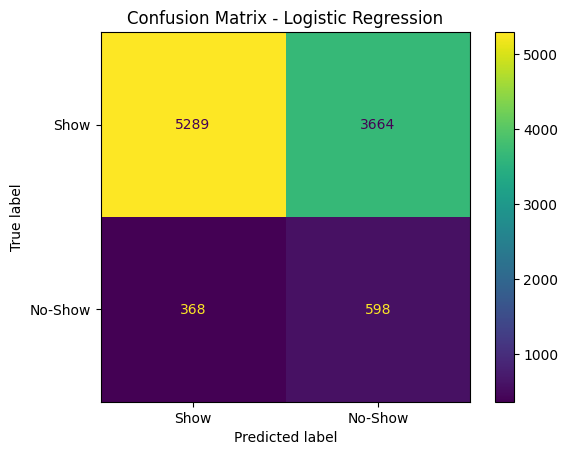

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Show", "No-Show"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Logistic Regression - Initial Evaluation

The Logistic Regression baseline detects **598 out of 966** true no-show appointments, corresponding to a recall of approximately **62%** for the no-show class.

However, the model also produces a large number of false positives:
- **3,664** appointments that were actually attended were incorrectly flagged as no-show risks.
- This results in a low precision of approximately **14%** for the no-show class.

From an operational perspective, this model may still be useful if the intervention is low-cost, such as automated SMS reminders. However, it may be less practical for expensive manual interventions such as phone calls, due to the high number of false alarms.

## Random Forest Model

After evaluating Logistic Regression as a baseline model, we now test a tree-based ensemble method.

Random Forest can capture more complex, non-linear relationships between variables and may perform better when no-show risk depends on interactions among features such as age, weather, specialty, and missing information patterns.

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [24]:
rf_y_pred = random_forest_model.predict(X_test)
rf_y_proba = random_forest_model.predict_proba(X_test)[:, 1]

In [25]:
print(classification_report(y_test, rf_y_pred))

rf_roc_auc = roc_auc_score(y_test, rf_y_proba)
rf_pr_auc = average_precision_score(y_test, rf_y_proba)

print(f"ROC-AUC: {rf_roc_auc:.3f}")
print(f"PR-AUC: {rf_pr_auc:.3f}")

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      8953
           1       0.48      0.22      0.30       966

    accuracy                           0.90      9919
   macro avg       0.70      0.60      0.62      9919
weighted avg       0.88      0.90      0.88      9919

ROC-AUC: 0.792
PR-AUC: 0.347


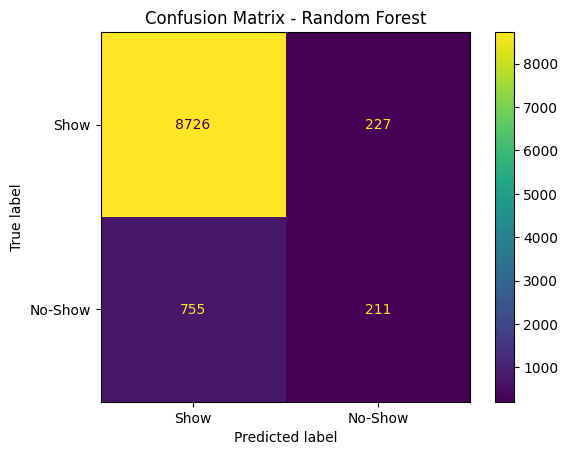

In [26]:
cm_rf = confusion_matrix(y_test, rf_y_pred)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Show", "No-Show"]
)

disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Threshold Tuning for Random Forest

The Random Forest model shows stronger ranking performance than Logistic Regression, but its default 0.50 threshold results in low recall for the no-show class.

To explore a more useful operational balance, we evaluate different classification thresholds and compare their precision, recall, and F1-score.

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

threshold_results = []

for threshold in thresholds:
    custom_pred = (rf_y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, custom_pred),
        "recall": recall_score(y_test, custom_pred),
        "f1_score": f1_score(y_test, custom_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.round(3)

,threshold,precision,recall,f1_score
0,0.50,0.485,0.222,0.304
1,0.45,0.468,0.260,0.334
2,0.40,0.451,0.302,0.362
3,0.35,0.438,0.360,0.395
4,0.30,0.409,0.403,0.406
5,0.25,0.381,0.455,0.415


### Threshold Tuning Insight

Lowering the classification threshold improves the model's ability to identify no-show appointments.

- At the default threshold of **0.50**, recall is only **22.2%**.
- At **0.30**, precision and recall become more balanced, both around **40%**.
- At **0.25**, the model achieves the highest tested **F1-score (0.415)** and increases recall to **45.5%**.

The preferred threshold depends on the operational cost of intervention:
- Lower thresholds may be suitable for low-cost actions such as automated reminders.
- Higher thresholds may be preferable when interventions require limited staff time, such as manual calls.

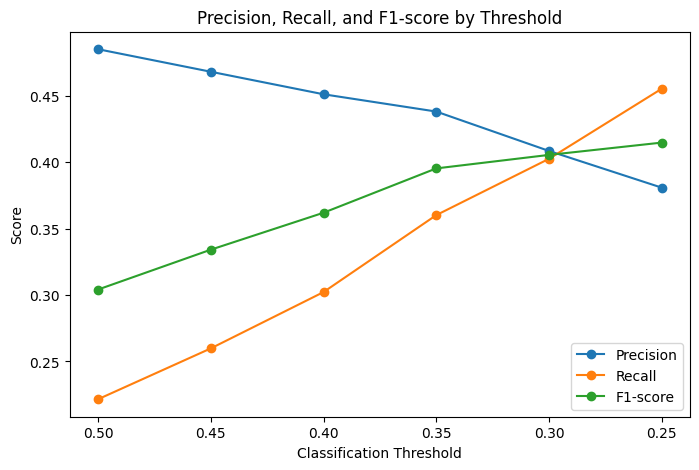

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    marker="o",
    label="F1-score"
)

plt.title("Precision, Recall, and F1-score by Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.gca().invert_xaxis()
plt.legend()

plt.show()

### Threshold Tuning Observation

As the threshold decreases, the model becomes less conservative in labeling appointments as no-show risks.

- **Recall increases**, meaning the model captures more true no-show cases.
- **Precision decreases**, meaning more false alarms are introduced.
- **F1-score improves** across the tested range and reaches its highest value at a threshold of **0.25**.

This confirms that the default threshold of **0.50** is not the most useful choice for this imbalanced healthcare problem.

In [29]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision_no_show": 0.14,
        "recall_no_show": 0.62,
        "f1_no_show": 0.23,
        "roc_auc": 0.638,
        "pr_auc": 0.152
    },
    {
        "model": "Random Forest",
        "precision_no_show": 0.48,
        "recall_no_show": 0.22,
        "f1_no_show": 0.30,
        "roc_auc": 0.792,
        "pr_auc": 0.347
    }
])

model_comparison

,model,precision_no_show,recall_no_show,f1_no_show,roc_auc,pr_auc
0,Logistic Regression,0.14,0.62,0.23,0.638,0.152
1,Random Forest,0.48,0.22,0.30,0.792,0.347


### Baseline Model Comparison

At the default classification threshold of **0.50**, the two models behave very differently:

- **Logistic Regression** captures a larger share of true no-show cases, with a recall of **0.62**, but its precision is very low (**0.14**). This means it flags many appointments as risky, but most of them are false alarms.
- **Random Forest** is much more selective. Its precision rises to **0.48**, meaning nearly half of the appointments it flags are actual no-shows. However, its recall drops to **0.22**, so it misses many true no-show cases at the default threshold.

Despite its lower default recall, **Random Forest shows clearly stronger overall discrimination**, with:
- Higher **ROC-AUC**: `0.792` vs `0.638`
- Higher **PR-AUC**: `0.347` vs `0.152`

This suggests that Random Forest is better at ranking appointments by no-show risk, and its performance can be improved by adjusting the classification threshold.

In [30]:
rf_threshold_comparison = pd.DataFrame([
    {
        "model": "Random Forest",
        "threshold": 0.50,
        "precision_no_show": 0.485,
        "recall_no_show": 0.222,
        "f1_no_show": 0.304
    },
    {
        "model": "Random Forest",
        "threshold": 0.30,
        "precision_no_show": 0.409,
        "recall_no_show": 0.403,
        "f1_no_show": 0.406
    },
    {
        "model": "Random Forest",
        "threshold": 0.25,
        "precision_no_show": 0.381,
        "recall_no_show": 0.455,
        "f1_no_show": 0.415
    }
])

rf_threshold_comparison

,model,threshold,precision_no_show,recall_no_show,f1_no_show
0,Random Forest,0.50,0.485,0.222,0.304
1,Random Forest,0.30,0.409,0.403,0.406
2,Random Forest,0.25,0.381,0.455,0.415


### Random Forest Threshold Comparison

Adjusting the classification threshold substantially changes the model's practical behavior.

- At the default threshold of **0.50**, the model is very selective:
  - Precision: **0.485**
  - Recall: **0.222**
- At a threshold of **0.30**, precision and recall become more balanced:
  - Precision: **0.409**
  - Recall: **0.403**
- At a threshold of **0.25**, the model achieves the highest tested F1-score:
  - Precision: **0.381**
  - Recall: **0.455**
  - F1-score: **0.415**

For this project, a threshold between **0.25 and 0.30** appears more operationally useful than the default **0.50**, depending on whether the priority is to capture more no-show cases or reduce unnecessary alerts.

## Gradient Boosting Model

After Logistic Regression and Random Forest, we test a boosting-based model.  
Gradient Boosting builds an ensemble of weak learners sequentially, with each step focusing on correcting previous errors. This may help capture more subtle patterns in no-show risk.

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

In [33]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [34]:
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [35]:
gb_y_pred = gradient_boosting_model.predict(X_test)
gb_y_proba = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [36]:
print(classification_report(y_test, gb_y_pred))

gb_roc_auc = roc_auc_score(y_test, gb_y_proba)
gb_pr_auc = average_precision_score(y_test, gb_y_proba)

print(f"ROC-AUC: {gb_roc_auc:.3f}")
print(f"PR-AUC: {gb_pr_auc:.3f}")

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      8953
           1       0.75      0.00      0.01       966

    accuracy                           0.90      9919
   macro avg       0.83      0.50      0.48      9919
weighted avg       0.89      0.90      0.86      9919

ROC-AUC: 0.686
PR-AUC: 0.226


### Gradient Boosting Evaluation

The Gradient Boosting model performs poorly for the no-show class at the default threshold.

Although the reported precision for no-show predictions is high, the recall is nearly zero, meaning that the model identifies almost none of the actual no-show appointments.

Its overall discrimination is also weaker than Random Forest:
- ROC-AUC: **0.686**
- PR-AUC: **0.226**

Since Random Forest achieved stronger ROC-AUC and PR-AUC scores and showed more useful threshold-tuning behavior, Gradient Boosting is not selected as the primary candidate model in this analysis.

In [37]:
final_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision_no_show": 0.14,
        "recall_no_show": 0.62,
        "f1_no_show": 0.23,
        "roc_auc": 0.638,
        "pr_auc": 0.152
    },
    {
        "model": "Random Forest",
        "precision_no_show": 0.48,
        "recall_no_show": 0.22,
        "f1_no_show": 0.30,
        "roc_auc": 0.792,
        "pr_auc": 0.347
    },
    {
        "model": "Gradient Boosting",
        "precision_no_show": 0.75,
        "recall_no_show": 0.00,
        "f1_no_show": 0.01,
        "roc_auc": 0.686,
        "pr_auc": 0.226
    }
])

final_model_comparison

,model,precision_no_show,recall_no_show,f1_no_show,roc_auc,pr_auc
0,Logistic Regression,0.14,0.62,0.23,0.638,0.152
1,Random Forest,0.48,0.22,0.30,0.792,0.347
2,Gradient Boosting,0.75,0.00,0.01,0.686,0.226


## Model Selection

Among the tested models, **Random Forest** is selected as the most promising candidate.

- Logistic Regression achieves the highest recall, but at the cost of very low precision and weaker overall discrimination.
- Gradient Boosting performs poorly for the no-show class and fails to identify a meaningful share of missed appointments.
- Random Forest provides the strongest overall separation between show and no-show cases, with the highest:
  - **ROC-AUC: 0.792**
  - **PR-AUC: 0.347**

Although its default threshold is too conservative, threshold tuning significantly improves its practical usefulness. Therefore, Random Forest is selected for further interpretation.

In [38]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

feature_names[:20]

array(['num__appointment_year', 'num__age', 'num__average_temp_day',
       'num__average_rain_day', 'num__max_temp_day', 'num__max_rain_day',
       'num__appointment_hour', 'cat__specialty_Missing',
       'cat__specialty_assist', 'cat__specialty_enf',
       'cat__specialty_occupational therapy', 'cat__specialty_pedagogo',
       'cat__specialty_physiotherapy', 'cat__specialty_psychotherapy',
       'cat__specialty_sem especialidade',
       'cat__specialty_speech therapy', 'cat__gender_F', 'cat__gender_I',
       'cat__gender_M', 'cat__disability_ '], dtype=object)

In [39]:
rf_classifier = random_forest_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
6,num__appointment_hour,0.107061
2,num__average_temp_day,0.088721
4,num__max_temp_day,0.081146
1,num__age,0.077144
0,num__appointment_year,0.053050
3,num__average_rain_day,0.044334
5,num__max_rain_day,0.040737
29,cat__city_ITAJAÍ,0.021614
13,cat__specialty_psychotherapy,0.021599
15,cat__specialty_speech therapy,0.021471


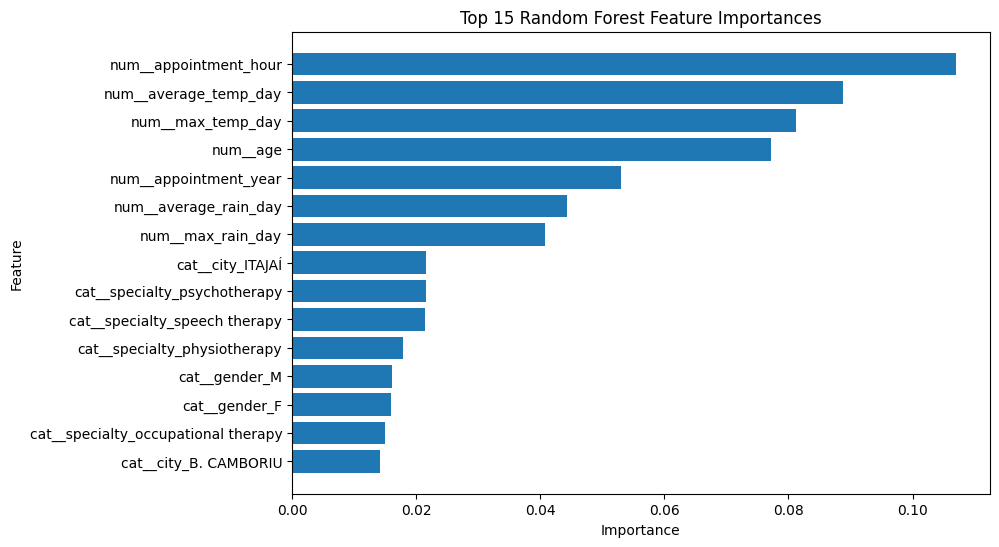

In [40]:
top_features = feature_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Random Forest Feature Importance - Initial View

The Random Forest model places the highest importance on:

- `appointment_hour`
- temperature-related variables
- `age`
- `appointment_year`
- rainfall-related variables

Several categorical variables, including city, specialty, gender, and day of the week, also contribute to the model's predictions.

However, these built-in Random Forest importances should be interpreted carefully. To obtain a more reliable view of feature relevance, we next evaluate **permutation importance** on the test set.

## Permutation Importance

In [41]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision"
)

In [42]:
permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
}).sort_values("importance_mean", ascending=False)

permutation_importance_df.head(15)

,feature,importance_mean,importance_std
4,appointment_month,0.072584,0.002703
5,appointment_year,0.059233,0.007815
3,city,0.053088,0.005600
20,appointment_hour,0.045840,0.005045
7,age,0.044041,0.001749
19,appointment_day_of_week,0.041575,0.005692
11,average_temp_day,0.040338,0.002530
1,gender,0.039492,0.005232
13,max_temp_day,0.026464,0.001362
6,appointment_shift,0.021864,0.002021


### Permutation Importance Insight

Permutation importance provides a more reliable view of feature relevance by measuring how much model performance decreases when each feature is randomly shuffled on the test set.

The most influential features for the selected Random Forest model are:

- `appointment_month`
- `appointment_year`
- `city`
- `appointment_hour`
- `age`
- `appointment_day_of_week`
- temperature-related variables

These results suggest that no-show risk is strongly connected to:
1. **Time-related patterns**,
2. **Geographic differences**,
3. **Patient age**,
4. **Weather conditions**.

The high importance of `appointment_month` and `appointment_year` is notable. This may reflect real temporal patterns in attendance behavior, but it also suggests that future work should consider evaluating the model with a **time-based train/test split** to assess how well it generalizes to later periods.

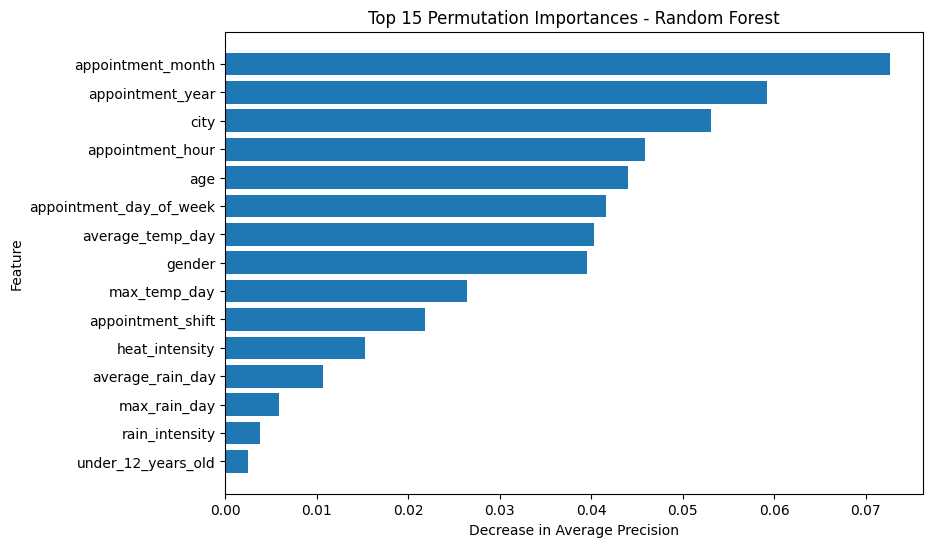

In [43]:
top_perm_features = permutation_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(9, 6))
plt.barh(top_perm_features["feature"], top_perm_features["importance_mean"])

plt.title("Top 15 Permutation Importances - Random Forest")
plt.xlabel("Decrease in Average Precision")
plt.ylabel("Feature")

plt.show()

## Final Modeling Summary

This modeling stage compared three approaches for predicting medical appointment no-shows:

1. **Logistic Regression**
2. **Random Forest**
3. **Gradient Boosting**

### Key results

- **Logistic Regression** achieved relatively high recall for no-show appointments (**0.62**), but precision was very low (**0.14**), meaning it generated many false alarms.
- **Random Forest** showed the strongest overall discrimination:
  - **ROC-AUC:** `0.792`
  - **PR-AUC:** `0.347`
- **Gradient Boosting** performed poorly for the no-show class and was not selected.

### Selected model

**Random Forest** was selected as the main model because it provided the best overall ability to rank appointments by no-show risk.

At the default threshold of `0.50`, it was too conservative, but threshold tuning improved its practical usefulness:

- At threshold `0.30`:
  - Precision: `0.409`
  - Recall: `0.403`
  - F1-score: `0.406`

- At threshold `0.25`:
  - Precision: `0.381`
  - Recall: `0.455`
  - F1-score: `0.415`

A threshold between **0.25 and 0.30** may be more useful than the default `0.50`, depending on the operational cost of the intervention.

### Model interpretation

Permutation importance suggests that the most relevant predictors include:

- Appointment month and year
- City
- Appointment hour
- Patient age
- Day of the week
- Temperature-related weather variables

These findings indicate that no-show behavior is influenced by a combination of:

- **Temporal patterns**
- **Geographic context**
- **Patient characteristics**
- **Weather conditions**

### Next step

The next stage is to evaluate the selected model more carefully from a practical decision-making perspective and prepare outputs that can later support:

- a business-facing summary,
- dashboard development,
- and deployment of a no-show risk prediction tool.

In [44]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

In [45]:
joblib.dump(
    random_forest_model,
    "../models/random_forest_no_show_pipeline.joblib"
)

['../models/random_forest_no_show_pipeline.joblib']